# EP04 — RNN vs Transformer Architecture
**Exam Relevance:** 2025 Q3 (4 marks)

This question tests whether you understand WHY sequential processing is both a strength and weakness, and how Transformers fix the main weakness.

---

## The Exam Question (2025 Q3)

> *RNNs process each input in a sequence sequentially.*
> - a) Why is this both an advantage and a drawback?
> - b) How does Transformer processing alleviate this drawback?

### Model Answer:

**a) Sequential processing:**
- **Advantage:** The hidden state carries context from previous tokens → naturally models sequential dependencies and ordering (useful for language, time series)
- **Drawback:** Cannot be parallelised during training → slow on long sequences; also suffers from vanishing gradients making it hard to remember long-range dependencies

**b) Transformers:**
- Process **all tokens simultaneously** using self-attention
- Every token attends to every other token in parallel → full parallelisation during training
- Long-range dependencies are captured directly through attention weights, not through a bottleneck hidden state

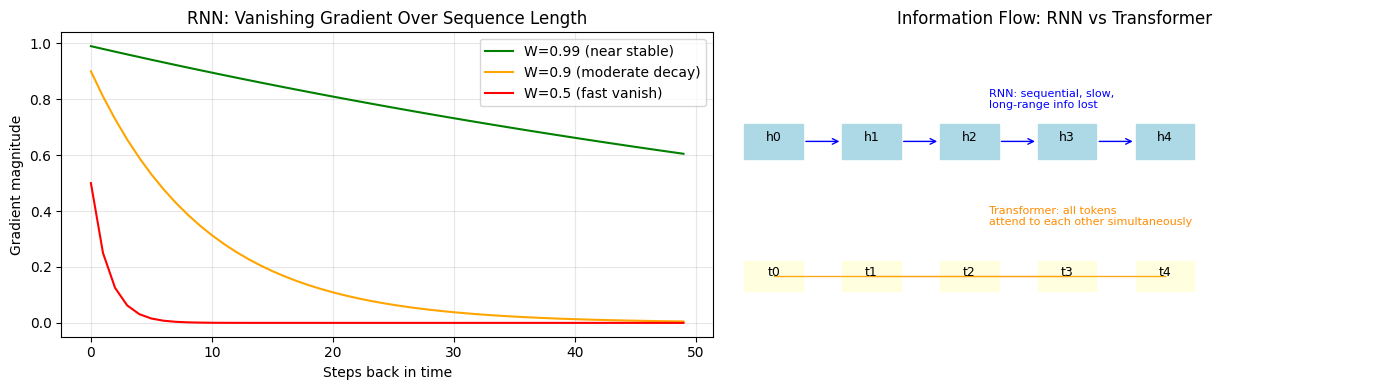

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Demonstrate the vanishing gradient problem in deep RNNs
# ============================================================

torch.manual_seed(0)

# Simulate gradient magnitude through time steps in a simple RNN
# gradient = product of (dh_t/dh_{t-1}) across all timesteps

def simulate_rnn_gradients(seq_len=50, W_hh_val=0.9):
    """Shows how gradient magnitude shrinks over many timesteps."""
    grad = 1.0
    grads = []
    for t in range(seq_len):
        # At each step, gradient is multiplied by W_hh (simplified)
        grad *= W_hh_val
        grads.append(grad)
    return grads

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: Vanishing gradient for different W values
for w, color, label in [(0.99, 'green', 'W=0.99 (near stable)'),
                         (0.9,  'orange', 'W=0.9 (moderate decay)'),
                         (0.5,  'red',   'W=0.5 (fast vanish)')]:
    axes[0].plot(simulate_rnn_gradients(50, w), color=color, label=label)

axes[0].set_xlabel('Steps back in time')
axes[0].set_ylabel('Gradient magnitude')
axes[0].set_title('RNN: Vanishing Gradient Over Sequence Length')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Conceptual diagram — RNN vs Transformer information flow
axes[1].set_xlim(0, 10)
axes[1].set_ylim(0, 6)
axes[1].axis('off')

# RNN chain
for i in range(5):
    axes[1].add_patch(plt.Rectangle((i*1.5+0.25, 3.5), 0.9, 0.7, fill=True, color='lightblue'))
    axes[1].text(i*1.5+0.7, 3.85, f'h{i}', ha='center', fontsize=9)
    if i < 4:
        axes[1].annotate('', xy=(i*1.5+1.5+0.25, 3.85), xytext=(i*1.5+0.25+0.9, 3.85),
                        arrowprops=dict(arrowstyle='->', color='blue'))
axes[1].text(4, 4.5, 'RNN: sequential, slow,\nlong-range info lost', fontsize=8, color='blue')

# Transformer all-to-all
positions = [(i*1.5+0.7, 1.2) for i in range(5)]
for i, (x, y) in enumerate(positions):
    axes[1].add_patch(plt.Rectangle((x-0.45, y-0.3), 0.9, 0.6, fill=True, color='lightyellow'))
    axes[1].text(x, y, f't{i}', ha='center', fontsize=9)

for i, (x1, y1) in enumerate(positions):
    for j, (x2, y2) in enumerate(positions):
        if i != j:
            axes[1].plot([x1, x2], [y1, y2], 'orange', alpha=0.3, linewidth=0.8)

axes[1].text(4, 2.2, 'Transformer: all tokens\nattend to each other simultaneously', fontsize=8, color='darkorange')
axes[1].set_title('Information Flow: RNN vs Transformer')

plt.tight_layout()
plt.show()

## Self-Attention — The Core of the Transformer

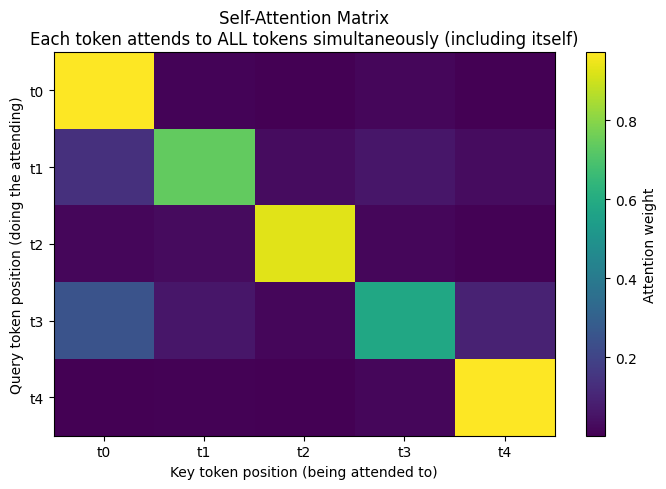

Key insight: In one forward pass, every token interacts with every other token.
An RNN would need T sequential steps to let token 0 influence token T-1.
A Transformer does it in 1 step (but requires O(T²) memory for the attention matrix).


In [2]:
# Simple self-attention implementation to understand what's happening
import torch
import torch.nn.functional as F

def self_attention(Q, K, V):
    """
    Scaled dot-product attention.
    Q, K, V: (seq_len, d_k)
    Returns: (seq_len, d_v) attended output
    """
    d_k = Q.shape[-1]
    # Attention scores: how much each token attends to each other
    scores = torch.matmul(Q, K.transpose(-2, -1)) / (d_k ** 0.5)
    # Softmax to get probabilities
    weights = F.softmax(scores, dim=-1)
    # Weighted sum of values
    output = torch.matmul(weights, V)
    return output, weights

# Example: 5-token sequence, dimension 8
torch.manual_seed(42)
seq_len, d_model = 5, 8
tokens = torch.randn(seq_len, d_model)

# Learnable projections (simplified: use identity for demo)
W_q = torch.eye(d_model)
W_k = torch.eye(d_model)
W_v = torch.eye(d_model)

Q = tokens @ W_q
K = tokens @ W_k
V = tokens @ W_v

output, attn_weights = self_attention(Q, K, V)

# Visualise attention weights
plt.figure(figsize=(7, 5))
plt.imshow(attn_weights.detach().numpy(), cmap='viridis', aspect='auto')
plt.colorbar(label='Attention weight')
plt.xlabel('Key token position (being attended to)')
plt.ylabel('Query token position (doing the attending)')
plt.title('Self-Attention Matrix\nEach token attends to ALL tokens simultaneously (including itself)')
plt.xticks(range(seq_len), [f't{i}' for i in range(seq_len)])
plt.yticks(range(seq_len), [f't{i}' for i in range(seq_len)])
plt.tight_layout()
plt.show()

print("Key insight: In one forward pass, every token interacts with every other token.")
print("An RNN would need T sequential steps to let token 0 influence token T-1.")
print("A Transformer does it in 1 step (but requires O(T²) memory for the attention matrix).")

## Exam Quick-Reference Summary

| | RNN | Transformer |
|---|---|---|
| Processing | Sequential (step by step) | Parallel (all at once) |
| Long-range deps | Weak (vanishing gradient) | Strong (direct attention) |
| Training speed | Slow on long sequences | Fast (parallelisable) |
| Memory | O(1) hidden state | O(T²) attention matrix |
| Key advantage | Inductive bias for ordering | Scales well, strong performance |

**For 2 marks per part — write exactly:**
- **Advantage:** sequential processing naturally captures temporal ordering / sequential dependencies in data
- **Drawback:** cannot be parallelised; also suffers from vanishing gradients making long-range dependencies hard to learn
- **Transformer fix:** processes all tokens simultaneously via self-attention — every token attends to every other token in a single parallel operation